In [1]:
#!/usr/bin/env python3

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, cohen_kappa_score,
    log_loss, balanced_accuracy_score
)
import true_threshold_ckks
import os
import time
import csv
import hashlib
import pickle
from typing import List, Dict, Tuple, Optional
import random
import tempfile


# ===============================
# Hash Utility Functions
# ===============================
def compute_hash(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def verify_hash(data: bytes, expected_hash: str) -> bool:
    return compute_hash(data) == expected_hash


# ===============================
# DKG-based TRUE Threshold HE Manager Wrapper
#
# Key difference from the original:
#   Original  → C++ KeyGen() produces one master keypair; Shamir splits the
#               single master secret.  The full secret EXISTS in one place.
#
#   DKG version → Each party independently samples its own secret s_i.
#                 The public key pk = Σ pk_i is assembled without any party
#                 ever seeing the combined secret s = Σ s_i.
#                 Threshold decryption still uses Lagrange interpolation over
#                 Shamir shares — but those shares come from each party's
#                 *own* s_i, not from a centralised secret.
#
# DKG Protocol (3 phases, all driven from Python):
#   Phase 1 – Secret generation : each party i calls dkg_generate_party_secret(i)
#   Phase 2 – Key aggregation   : collect pk_i bytes, call dkg_finalize_public_key()
#   Phase 3 – Shamir sharing    : generate_key_shares() now splits each party's
#                                 own s_i; combined shares are handed to
#                                 construct_party_key() as before.
# ===============================
class TrueThresholdCKKSWrapper:
    def __init__(self, num_parties: int, threshold: int, ring_dim: int = 8192,
                 batch_size: int = 4096, mult_depth: int = 10, scale_bits: int = 50):
        self.num_parties = num_parties
        self.threshold   = threshold
        self.batch_size  = batch_size
        self.ring_dim    = ring_dim

        print(f"[HE Manager] Initialising DKG-based TRUE threshold CKKS")
        print(f"  Threshold : {threshold}-of-{num_parties}")
        print(f"  Ring dim  : {ring_dim},  Batch size: {batch_size}")

        self.ckks = true_threshold_ckks.TrueThresholdCKKS(
            num_parties = num_parties,
            threshold   = threshold,
            ring_dim    = ring_dim,
            batch_size  = batch_size,
            mult_depth  = mult_depth,
            scale_bits  = scale_bits
        )

        # ── Phase 1: chain-based DKG key generation ─────────────────────────
        print(f"\n[HE Manager] DKG Phase 1 – chain key generation")
        # Party 1 is lead
        pk_bytes = self.ckks.dkg_lead_keygen()
        print(f"  Party 1 (lead) done")
        # Parties 2..n join the chain sequentially
        for party_id in range(2, num_parties + 1):
            pk_bytes = self.ckks.dkg_join_keygen(party_id, pk_bytes)
            print(f"  Party {party_id} (join) done")

        # ── Phase 2: finalize joint public key ───────────────────────────────
        # The last party's chained pk IS the joint pk
        print(f"\n[HE Manager] DKG Phase 2 – finalizing joint public key")
        self.ckks.dkg_finalize_public_key(pk_bytes)
        print(f"[HE Manager] Joint pk ready — combined secret was NEVER assembled")

        # ── Phase 3: EvalMult collaborative keygen ───────────────────────────
        print(f"\n[HE Manager] DKG Phase 3 – collaborative EvalMult key")
        eval_bytes = self.ckks.dkg_evalmult_keygen(1)
        for party_id in range(2, num_parties + 1):
            eval_bytes = self.ckks.dkg_evalmult_join(party_id, eval_bytes)
        self.ckks.dkg_evalmult_finalize(eval_bytes)
        print(f"[HE Manager] EvalMult key ready")

        # ── Phase 4: Shamir backup shares (key recovery / threshold decrypt) ─
        print(f"\n[HE Manager] DKG Phase 4 – Shamir backup shares")
        # Each party i splits its own s_i into (t,n) shares
        # Party j's combined share = sum of share_i(j) for all i
        # We simulate this by summing across parties per recipient
        combined_shares = {}   # recipient_id -> combined share coeffs

        for party_id in range(1, num_parties + 1):
            shares = self.ckks.generate_key_shares(
                party_id, threshold, num_parties)
            for recipient_idx in range(num_parties):
                recipient_id = recipient_idx + 1
                if recipient_id not in combined_shares:
                    combined_shares[recipient_id] = np.zeros(
                        len(shares[recipient_idx]), dtype=np.int64)
                combined_shares[recipient_id] += shares[recipient_idx]

        # Register each party's combined Shamir share key
        for party_id in range(1, num_parties + 1):
            self.ckks.construct_party_key(
                party_id,
                combined_shares[party_id]
            )
            print(f"  Party {party_id} Shamir key registered")

        print(f"\n[HE Manager] DKG complete – system ready")
        print(f"[HE Manager] The combined secret s = Σ s_i was NEVER assembled.")

    def get_batch_size(self) -> int:
        return self.batch_size

    def encrypt_to_bytes(self, data: np.ndarray) -> bytes:
        if len(data) > self.batch_size:
            raise ValueError(
                f"Data size {len(data)} exceeds batch size {self.batch_size}")
        if len(data) < self.batch_size:
            padded = np.zeros(self.batch_size)
            padded[:len(data)] = data
            data = padded
        return self.ckks.encrypt(data)

    def add_encrypted(self, ct1: bytes, ct2: bytes) -> bytes:
        return self.ckks.add_encrypted(ct1, ct2)

    def multiply_encrypted_by_scalar(self, ct: bytes, scalar: float) -> bytes:
        return self.ckks.multiply_by_scalar(ct, scalar)

    def threshold_decrypt(self, ciphertext: bytes,
                        party_indices: np.ndarray) -> np.ndarray:
        """
        Path B: Shamir partial decrypt + Lagrange combination.
        Works on any ciphertext including homomorphically aggregated ones.
        party_indices: 1-based party IDs, exactly `threshold` of them.
        """
        participating = [int(p) for p in party_indices]

        # Each participating party produces a partial decryption
        # using its Shamir share key
        partial_decryptions = []
        for party_id in participating:
            partial = self.ckks.partial_decrypt_shamir(
                party_id,
                ciphertext
            )
            partial_decryptions.append(partial)

        # Lagrange interpolation combines the partials
        return self.ckks.combine_partial_decryptions(
            partial_decryptions,
            participating
        )
# ===============================
# Dataset Loader (unchanged)
# ===============================
class InSDNDataset:
    def __init__(self):
        self.scaler = StandardScaler()

    def load_data(self):
        df = pd.read_csv("final_cicids2017_top48_features.csv")
        y  = df['Label'].values.astype(np.int32)
        X  = df.drop(columns=['Label']).values.astype(np.float64)
        print(f"Data loaded: {len(df)} rows")
        X_scaled = self.scaler.fit_transform(X)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.3, random_state=42, stratify=y
        )
        return X_train, X_test, y_train, y_test

    def preprocess(self, X_train, X_test):
        timesteps = 1
        features  = X_train.shape[1]
        return X_train.reshape(-1, timesteps, features), \
               X_test.reshape(-1, timesteps, features)


# ===============================
# GRU Model (unchanged)
# ===============================
def build_gru_model(input_shape, lr=0.0001):
    model = Sequential([
        GRU(256, return_sequences=True, input_shape=input_shape),
        BatchNormalization(), Dropout(0.3),
        GRU(128, return_sequences=True),
        BatchNormalization(), Dropout(0.3),
        GRU(64,  return_sequences=False),
        BatchNormalization(), Dropout(0.3),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


# ===============================
# Utility functions (unchanged)
# ===============================
def load_csv_data(file_path):
    df     = pd.read_csv(file_path)
    data   = df.iloc[:, :-1].values
    labels = df.iloc[:, -1].values
    return data, labels

def create_clients(data_list, label_list, num_clients=10, initial='clients'):
    client_names = [f'{initial}_{i+1}' for i in range(num_clients)]
    data = list(zip(data_list, label_list))
    random.shuffle(data)
    size   = len(data) // num_clients
    shards = [data[i:i + size] for i in range(0, size * num_clients, size)]
    return {client_names[i]: shards[i] for i in range(len(client_names))}

def batch_data(data_shard, bs=32):
    data, label = zip(*data_shard)
    dataset = tf.data.Dataset.from_tensor_slices((list(data), list(label)))
    return dataset.shuffle(len(label)).batch(bs)

def weight_scaling_factor(clients_trn_data, client_name):
    client_names  = list(clients_trn_data.keys())
    bs            = list(clients_trn_data[client_name])[0][0].shape[0]
    global_count  = sum(
        tf.data.experimental.cardinality(clients_trn_data[n]).numpy()
        for n in client_names
    ) * bs
    local_count   = tf.data.experimental.cardinality(
        clients_trn_data[client_name]).numpy() * bs
    return local_count / global_count

def test_model(X_test, Y_test, model, comm_round):
    logits  = model.predict(X_test)
    y_pred  = (logits > 0.5).astype(int)
    y_true  = Y_test.numpy().ravel()
    acc     = accuracy_score(y_true, y_pred)
    prec    = precision_score(y_true, y_pred, average='binary')
    rec     = recall_score(y_true, y_pred, average='binary')
    f1      = f1_score(y_true, y_pred, average='binary')
    mcc     = matthews_corrcoef(y_true, y_pred)
    kappa   = cohen_kappa_score(y_true, y_pred)
    logloss = log_loss(y_true, logits)
    g_mean  = balanced_accuracy_score(y_true, y_pred)
    return acc, prec, rec, f1, mcc, kappa, logloss, g_mean, 0

def get_model_size(model):
    tmpdir = tempfile.mkdtemp()
    path   = os.path.join(tmpdir, 'tmp.h5')
    try:
        model.save(path)
        size = os.path.getsize(path) / (1024 * 1024)
    finally:
        if os.path.exists(path):   os.remove(path)
        if os.path.exists(tmpdir): os.rmdir(tmpdir)
    return size

def measure_communication_overhead(weights, num_clients):
    import pickle as pkl
    serialized          = pkl.dumps(weights)
    weights_size        = len(serialized)
    server_to_clients   = weights_size * num_clients
    clients_to_server   = weights_size * num_clients
    return {
        'server_to_clients': server_to_clients,
        'clients_to_server': clients_to_server,
        'total_round'      : server_to_clients + clients_to_server,
        'weights_size'     : weights_size,
    }

def measure_computation_time():
    class ComputationTimer:
        def __enter__(self):
            self.start_time = time.time(); return self
        def __exit__(self, *_):
            self.elapsed_time = time.time() - self.start_time
    return ComputationTimer()


# ===============================
# Federated Server (unchanged)
# ===============================
class FLServer:
    def __init__(self, num_clients, byzantine_threshold, he_manager):
        self.he                         = he_manager
        self.num_clients                = num_clients
        self.byzantine_threshold        = byzantine_threshold
        self.registered_clients         = {}
        self.registration_tokens        = {}
        self.client_hashes              = {}
        self.aggregated_hash            = None
        self.suspicious_clients         = set()
        self.malicious_updates_detected = 0
        self.encrypted_aggregated       = None

    def register_client(self, client_id, dataset_size):
        if client_id in self.registered_clients:
            return False, None
        token_data = f"{client_id}_{dataset_size}_{time.time()}"
        token      = hashlib.sha256(token_data.encode()).hexdigest()
        self.registered_clients[client_id] = {
            'token': token, 'dataset_size': dataset_size,
            'registration_time': time.time()
        }
        self.registration_tokens[token] = client_id
        print(f"[Server] Client {client_id} registered (Dataset size: {dataset_size})")
        return True, token

    def verify_client_registration(self, client_id):
        return client_id in self.registered_clients

    def receive_encrypted_update(self, client_id, encrypted_chunks, hashes):
        if not self.verify_client_registration(client_id):
            print(f"[Server] Client {client_id} not registered!")
            return False
        if not self._verify_update_integrity(encrypted_chunks, hashes):
            print(f"[Server] Hash verification failed for Client {client_id}")
            self.suspicious_clients.add(client_id)
            return False
        self.client_hashes[client_id] = hashes
        print(f"[Server] Client {client_id} update verified ({len(hashes)} chunks)")
        return True

    def _verify_update_integrity(self, encrypted_chunks, provided_hashes):
        if len(encrypted_chunks) != len(provided_hashes): return False
        for chunk, expected in zip(encrypted_chunks, provided_hashes):
            if compute_hash(chunk) != expected: return False
        return True

    def detect_byzantine_behavior(self, encrypted_updates, client_ids):
        update_sizes   = [sum(len(c) for c in u) for u in encrypted_updates]
        mean_size      = np.mean(update_sizes)
        std_size       = np.std(update_sizes)
        malicious      = []
        for size, cid in zip(update_sizes, client_ids):
            if abs(size - mean_size) > 3 * std_size:
                malicious.append(cid)
                self.suspicious_clients.add(cid)
                print(f"[Server] Byzantine behaviour detected: Client {cid}")
        attack = len(malicious) >= self.byzantine_threshold
        if attack:
            self.malicious_updates_detected += 1
            print(f"[Server] BYZANTINE ATTACK DETECTED! {len(malicious)} malicious clients")
        return attack, malicious

    def weighted_aggregate_encrypted(self, encrypted_weights_list,
                                     scaling_factors, client_ids):
        print("[Server] Performing Byzantine-resistant secure weighted aggregation...")
        attack, malicious = self.detect_byzantine_behavior(
            encrypted_weights_list, client_ids)
        if attack:
            print("[Server] ABORTING AGGREGATION – Byzantine attack detected!")
            return None, None

        if self.suspicious_clients:
            filtered = [(u, f, cid)
                        for u, f, cid in zip(encrypted_weights_list,
                                             scaling_factors, client_ids)
                        if cid not in self.suspicious_clients]
            if not filtered:
                print("[Server] No valid updates remaining after filtering!")
                return None, None
            encrypted_weights_list, scaling_factors, client_ids = zip(*filtered)
            print(f"[Server] Continuing with {len(client_ids)} trusted clients: "
                  f"{list(client_ids)}")

        num_chunks        = len(encrypted_weights_list[0])
        aggregated_chunks = []

        for chunk_idx in range(num_chunks):
            weighted = self.he.multiply_encrypted_by_scalar(
                encrypted_weights_list[0][chunk_idx], float(scaling_factors[0]))
            for ci in range(1, len(encrypted_weights_list)):
                w_i = self.he.multiply_encrypted_by_scalar(
                    encrypted_weights_list[ci][chunk_idx], float(scaling_factors[ci]))
                weighted = self.he.add_encrypted(weighted, w_i)
            aggregated_chunks.append(weighted)

        combined_data    = b''.join(aggregated_chunks)
        aggregated_hash  = compute_hash(combined_data)
        self.encrypted_aggregated = aggregated_chunks
        self.aggregated_hash      = aggregated_hash

        print(f"[Server] Aggregation complete "
              f"(scaling factors: {[f'{s:.4f}' for s in scaling_factors]})")
        print(f"[Server] Aggregated hash: {aggregated_hash[:32]}...")
        return aggregated_chunks, aggregated_hash


# ===============================
# Encrypt / Decrypt helpers (unchanged)
# ===============================
def encrypt_weights(he_manager, weights) -> Tuple[List[bytes], List[str]]:
    flat       = np.concatenate([w.flatten() for w in weights])
    slot_limit = he_manager.get_batch_size()
    encrypted_chunks, hashes = [], []
    for i in range(0, len(flat), slot_limit):
        chunk     = flat[i:i + slot_limit]
        enc_chunk = he_manager.encrypt_to_bytes(chunk)
        encrypted_chunks.append(enc_chunk)
        hashes.append(compute_hash(enc_chunk))
    return encrypted_chunks, hashes


def decrypt_aggregated(he_manager, encrypted_aggregated,
                        party_indices, reference_weights):
    decrypted_chunks = [
        he_manager.threshold_decrypt(enc, party_indices)
        for enc in encrypted_aggregated
    ]
    flat_weights = np.concatenate(decrypted_chunks)
    new_weights, idx = [], 0
    for w in reference_weights:
        size = np.prod(w.shape)
        new_weights.append(flat_weights[idx:idx + size].reshape(w.shape))
        idx += size
    return new_weights


def verify_aggregated_integrity(encrypted_aggregated, aggregated_hash):
    return compute_hash(b''.join(encrypted_aggregated)) == aggregated_hash


# ===============================
# Main
# ===============================

print("=" * 70)
print("FEDERATED LEARNING WITH DKG-BASED TRUE THRESHOLD HOMOMORPHIC ENCRYPTION")
print("=" * 70)

results_dir = '4_InSDN_dkg_true'
os.makedirs(results_dir, exist_ok=True)

# ── Data loading ───────────────────────────────────────────────────────
data_path = "../Final_Binary_InSDN_Dataset.csv"
data_list, label_list = load_csv_data(data_path)
print(len(np.unique(label_list)))

scaler    = StandardScaler()
data_list = scaler.fit_transform(data_list)

X_train, X_test, y_train, y_test = train_test_split(
    data_list, label_list, test_size=0.3, random_state=42, stratify=label_list)

X_train = np.expand_dims(X_train, axis=1)
X_test  = np.expand_dims(X_test,  axis=1)

# ── FL settings ────────────────────────────────────────────────────────
comms_round       = 15
lr                = 0.0001
num_clients       = 4
threshold         = 3
byzantine_threshold = 2

clients        = create_clients(X_train, y_train,
                                num_clients=num_clients, initial='client')
clients_batched = {name: batch_data(data)
                   for name, data in clients.items()}
test_batched    = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)).batch(len(y_test))

# ── Initialise DKG-based HE ────────────────────────────────────────────
print("\n" + "=" * 70)
print("INITIALISING DKG-BASED TRUE THRESHOLD HOMOMORPHIC ENCRYPTION")
print("=" * 70)

# TrueThresholdCKKSWrapper now runs the full 3-phase DKG internally.
he_manager = TrueThresholdCKKSWrapper(
    num_parties = num_clients,
    threshold   = threshold,
    ring_dim    = 8192,
    batch_size  = 4096,
    mult_depth  = 2,
    scale_bits  = 40
)

# ── Server & client registration ───────────────────────────────────────
server       = FLServer(num_clients, byzantine_threshold, he_manager)
client_names = list(clients_batched.keys())

print(f"\n{'=' * 70}")
print("CLIENT REGISTRATION PHASE")
print(f"{'=' * 70}")
for i, client_name in enumerate(client_names):
    dataset_size = len(list(clients_batched[client_name])) * 32
    success, _   = server.register_client(i, dataset_size)
    if not success:
        print(f"[FATAL] Client {client_name} registration failed!");
print(f"\nAll {num_clients} clients registered successfully")

# ── Model & CSV setup ──────────────────────────────────────────────────
input_shape  = (X_train.shape[1], X_train.shape[2])
global_model = build_gru_model(input_shape, lr=lr)

out_client  = os.path.join(results_dir, "dkg_client_metrics_4.csv")
out_global  = os.path.join(results_dir, "dkg_each_round_metrics_4.csv")
out_comm    = os.path.join(results_dir, "dkg_communication_computation_metrics_4.csv")

with open(out_client, 'w', newline='') as f:
    csv.writer(f).writerow(["Communication Round", "Client", "Loss", "Accuracy",
                             "Precision", "Recall", "auc",
                             "Encryption_Time_sec", "Decryption_Time_sec"])
with open(out_global, 'w', newline='') as f:
    csv.writer(f).writerow(["comm_round", "global_acc", "global_precision",
                             "global_recall", "global_f1", "global_mcc",
                             "global_cohen_kappa", "global_logloss",
                             "global_g_mean", "global_loss"])
with open(out_comm, 'w', newline='') as f:
    csv.writer(f).writerow([
        "comm_round", "server_to_clients_mb", "clients_to_server_mb",
        "total_round_mb", "weights_size_mb", "encrypted_weights_size_mb",
        "encryption_overhead_mb", "round_computation_time_sec",
        "avg_client_training_time_sec", "weight_aggregation_time_sec",
        "avg_encryption_time_sec", "avg_decryption_time_sec",
        "encryption_time_sec", "decryption_time_sec", "aggregation_time_sec"])

# ── Tracking variables ─────────────────────────────────────────────────
total_communication_overhead = 0
total_computation_time       = 0
total_encryption_time        = 0
total_decryption_time        = 0
total_aggregation_time       = 0
total_encryption_overhead    = 0

encrypted_global_weights = None
encrypted_weights_size_mb = 0.0

# ── Training loop ──────────────────────────────────────────────────────
for comm_round in range(comms_round):
    print(f"\n{'=' * 70}")
    print(f"COMMUNICATION ROUND {comm_round + 1}/{comms_round}")
    print(f"{'=' * 70}")

    with measure_computation_time() as round_timer:

        global_weights    = global_model.get_weights()
        decryption_times  = []
        round_decryption_time = 0

        # Decrypt previous round's aggregated model (if any)
        if comm_round > 0 and encrypted_global_weights is not None:
            print("[CLIENTS] Decrypting aggregated model...")
            t0 = time.time()

            dec_indices  = sorted(random.sample(range(num_clients), threshold))
            party_indices = np.array([idx + 1 for idx in dec_indices], dtype=np.int32)
            print(f"[Decryption] Selected parties: {dec_indices}")

            current_weights = decrypt_aggregated(
                he_manager, encrypted_global_weights,
                party_indices, global_model.get_weights())

            decrypt_time = time.time() - t0
            decryption_times.append(decrypt_time)
            round_decryption_time = decrypt_time
            total_decryption_time += decrypt_time
            print(f"Decryption: {decrypt_time:.2f}s")
        else:
            current_weights = global_weights
            decrypt_time    = 0

        comm_overhead = measure_communication_overhead(current_weights, num_clients)
        comm_mb       = {k: v / (1024 * 1024) for k, v in comm_overhead.items()}

        random.shuffle(client_names)

        client_training_times = []
        encryption_times      = []
        round_encryption_time = 0
        encrypted_updates     = []
        update_hashes_list    = []
        participating_clients = []
        scaling_factors       = []

        for client in client_names:
            client_idx = client_names.index(client)
            print(f"\n[{client}] Local training...")

            with measure_computation_time() as ct:
                local_model = build_gru_model(input_shape, lr=lr)
                local_model.set_weights(current_weights)
                history = local_model.fit(clients_batched[client],
                                          epochs=5, verbose=1)

            client_training_times.append(ct.elapsed_time)
            trained_weights = local_model.get_weights()

            print(f"[{client}] Encrypting weights...")
            t0 = time.time()
            enc_chunks, hashes = encrypt_weights(he_manager, trained_weights)
            encrypt_time = time.time() - t0
            encryption_times.append(encrypt_time)
            round_encryption_time += encrypt_time
            total_encryption_time += encrypt_time
            print(f"Encryption: {encrypt_time:.2f}s")

            sf = weight_scaling_factor(clients_batched, client)
            if server.receive_encrypted_update(client_idx, enc_chunks, hashes):
                encrypted_updates.append(enc_chunks)
                update_hashes_list.append(hashes)
                participating_clients.append(client_idx)
                scaling_factors.append(sf)
                print(f"Server accepted model from {client}")
            else:
                print(f"Server rejected model from {client}")

            with open(out_client, 'a', newline='') as f:
                csv.writer(f).writerow([
                    comm_round, client,
                    history.history['loss'][-1],
                    history.history['accuracy'][-1],
                    0, 0, 0, encrypt_time, decrypt_time])

            tf.keras.backend.clear_session()

        if len(participating_clients) < threshold:
            print(f"\nWARNING: Only {len(participating_clients)} clients, "
                  f"need {threshold}. Skipping round.")
            continue

        # Server-side secure aggregation
        print(f"\n[SERVER] Secure aggregation (homomorphic weighted sum)...")
        with measure_computation_time() as agg_timer:
            aggregated_chunks, aggregated_hash = \
                server.weighted_aggregate_encrypted(
                    encrypted_updates, scaling_factors, participating_clients)

        total_aggregation_time += agg_timer.elapsed_time
        print(f"Aggregation: {agg_timer.elapsed_time:.2f}s")

        if aggregated_chunks is None:
            print(f"ROUND {comm_round + 1} ABORTED – Byzantine attack detected!")
            server.suspicious_clients.clear()
            continue

        print(f"\n[Hash Verification] Verifying aggregated result...")
        if not verify_aggregated_integrity(aggregated_chunks, aggregated_hash):
            print(f"ROUND {comm_round + 1} ABORTED – Hash verification failed!")
            continue
        print("Aggregated hash verified ✓")

        encrypted_global_weights  = aggregated_chunks
        encrypted_weights_size    = sum(len(c) for c in encrypted_global_weights)
        encrypted_weights_size_mb = encrypted_weights_size / (1024 * 1024)
        encryption_overhead_mb    = (encrypted_weights_size -
                                     comm_overhead['weights_size']) / (1024 * 1024)
        total_encryption_overhead += (encrypted_weights_size -
                                      comm_overhead['weights_size'])

        # Final decryption for evaluation
        print(f"\n[CLIENTS] Decrypting aggregated model for evaluation...")
        t0 = time.time()
        fin_indices   = sorted(random.sample(range(num_clients), threshold))
        party_final   = np.array([idx + 1 for idx in fin_indices], dtype=np.int32)
        final_weights = decrypt_aggregated(
            he_manager, encrypted_global_weights,
            party_final, global_model.get_weights())
        final_dec_time = time.time() - t0
        total_decryption_time += final_dec_time
        print(f"Final decryption: {final_dec_time:.2f}s")

        global_model.set_weights(final_weights)

    total_computation_time        += round_timer.elapsed_time
    total_communication_overhead  += encrypted_weights_size * num_clients * 2

    avg_client_training = np.mean(client_training_times)
    avg_enc_time        = np.mean(encryption_times)
    avg_dec_time        = np.mean(decryption_times) if decryption_times else 0

    with open(out_comm, 'a', newline='') as f:
        csv.writer(f).writerow([
            comm_round,
            comm_mb['server_to_clients'], comm_mb['clients_to_server'],
            comm_mb['total_round'],       comm_mb['weights_size'],
            encrypted_weights_size_mb,    encryption_overhead_mb,
            round_timer.elapsed_time,     avg_client_training,
            agg_timer.elapsed_time,       avg_enc_time,
            avg_dec_time,                 round_encryption_time,
            round_decryption_time,        agg_timer.elapsed_time])

    for X_batch, Y_batch in test_batched:
        (global_acc, global_precision, global_recall, global_f1,
         global_mcc, global_kappa, global_logloss,
         global_g_mean, global_loss) = test_model(X_batch, Y_batch,
                                                   global_model, comm_round)
        print(f'comm_round: {comm_round} | '
              f'global_acc: {global_acc:.3%} | '
              f'global_precision: {global_precision:.3%} | '
              f'global_recall: {global_recall:.3%} | '
              f'global_f1: {global_f1:.3%} | '
              f'global_mcc: {global_mcc:.3%} | '
              f'global_cohen_kappa: {global_kappa:.3} | '
              f'global_logloss: {global_logloss:.3%} | '
              f'global_g_mean: {global_g_mean:.3}')

    with open(out_global, 'a', newline='') as f:
        csv.writer(f).writerow([
            comm_round, global_acc, global_precision, global_recall,
            global_f1, global_mcc, global_kappa, global_logloss,
            global_g_mean, global_loss])

# ── Final summary ──────────────────────────────────────────────────────
print(f"\n{'=' * 70}")
print(f"FINAL DKG TRUE THRESHOLD FEDERATED LEARNING SUMMARY")
print(f"{'=' * 70}")
print(f"Total Communication Overhead : "
      f"{total_communication_overhead / (1024 * 1024):.2f} MB")
print(f"Total Computation Time       : {total_computation_time:.2f}s")
print(f"Total Encryption Time        : {total_encryption_time:.2f}s")
print(f"Total Decryption Time        : {total_decryption_time:.2f}s")
print(f"Total Aggregation Time       : {total_aggregation_time:.2f}s")
print(f"Avg Communication per Round  : "
      f"{(total_communication_overhead / comms_round) / (1024 * 1024):.2f} MB")
print(f"Avg Computation per Round    : "
      f"{total_computation_time / comms_round:.2f}s")

summary = {
    'total_communication_mb'         : total_communication_overhead / (1024 * 1024),
    'total_computation_time_sec'     : total_computation_time,
    'total_encryption_time_sec'      : total_encryption_time,
    'total_decryption_time_sec'      : total_decryption_time,
    'total_aggregation_time_sec'     : total_aggregation_time,
    'avg_communication_per_round_mb' : (total_communication_overhead / comms_round) / (1024 * 1024),
    'avg_computation_per_round_sec'  : total_computation_time / comms_round,
    'num_rounds'  : comms_round,
    'num_clients' : num_clients,
    'threshold'   : threshold,
    'dkg_enabled' : True,
}
summary_path = os.path.join(results_dir, "dkg_summary_metrics_4.csv")
with open(summary_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(["Metric", "Value"])
    for k, v in summary.items():
        w.writerow([k, v])

for X_batch, Y_batch in test_batched:
    (acc, prec, rec, f1, mcc, kappa,
     logloss, g_mean, _) = test_model(X_batch, Y_batch, global_model, 0)
    print(f'Final Results | '
          f'acc: {acc:.3%} | prec: {prec:.3%} | recall: {rec:.3%} | '
          f'f1: {f1:.3%} | mcc: {mcc:.3%} | kappa: {kappa:.3} | '
          f'logloss: {logloss:.3%} | g_mean: {g_mean:.3}')

global_model.save(os.path.join(results_dir, 'dkg_Federated_model_4.h5'))

# ── Centralised baseline ───────────────────────────────────────────────
print(f"\n{'=' * 70}")
print(f"CENTRALISED TRAINING FOR COMPARISON")
print(f"{'=' * 70}")
with measure_computation_time() as ct:
    sgd_ds    = tf.data.Dataset.from_tensor_slices(
        (X_train, y_train)).shuffle(len(y_train)).batch(512)
    sgd_model = build_gru_model(input_shape, lr=0.001)
    sgd_model.fit(sgd_ds, epochs=1, verbose=True)
print(f"Centralised training time: {ct.elapsed_time:.2f}s")

for X_batch, Y_batch in test_batched:
    (acc, prec, rec, f1, mcc, kappa,
     logloss, g_mean, _) = test_model(X_batch, Y_batch, sgd_model, 1)
    print(f'Centralised | '
          f'acc: {acc:.3%} | prec: {prec:.3%} | recall: {rec:.3%} | '
          f'f1: {f1:.3%} | mcc: {mcc:.3%} | kappa: {kappa:.3} | '
          f'logloss: {logloss:.3%} | g_mean: {g_mean:.3}')

print("\n" + "=" * 70)
print("ALL TRAINING COMPLETE!")
print("=" * 70)

blacklisted = server.suspicious_clients
print(f"\nBlacklisted malicious clients: {blacklisted}"
      if blacklisted else "\nNo malicious clients detected during training")

2026-04-24 08:40:38.983775: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-24 08:40:39.010284: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


FEDERATED LEARNING WITH DKG-BASED TRUE THRESHOLD HOMOMORPHIC ENCRYPTION
2


2026-04-24 08:40:42.577046: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-24 08:40:42.579678: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-24 08:40:42.579766: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf


INITIALISING DKG-BASED TRUE THRESHOLD HOMOMORPHIC ENCRYPTION
[HE Manager] Initialising DKG-based TRUE threshold CKKS
  Threshold : 3-of-4
  Ring dim  : 8192,  Batch size: 4096

[HE Manager] DKG Phase 1 – chain key generation
  Party 1 (lead) done
  Party 2 (join) done
  Party 3 (join) done
[TrueThresholdCKKS] Context ready. ring_dim=8192 batch_size=4096 mult_depth=2 scale_bits=40 threshold=3-of-4 mode=NOISE_FLOODING_MULTIPARTY
  Party 4 (join) done

[HE Manager] DKG Phase 2 – finalizing joint public key
[HE Manager] Joint pk ready — combined secret was NEVER assembled

[HE Manager] DKG Phase 3 – collaborative EvalMult key
[DKG] Party 1 (lead) keypair generated. s_1 stored (8192 coeffs).
[DKG] Party 2 (join) keypair generated. s_2 stored (8192 coeffs).
[DKG] Party 3 (join) keypair generated. s_3 stored (8192 coeffs).
[DKG] Party 4 (join) keypair generated. s_4 stored (8192 coeffs).
[DKG] Joint public key finalized. Joint secret s=Σs_i was NEVER assembled in one place.
[DKG] Party 1 Eva

2026-04-24 08:40:50.877479: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2026-04-24 08:40:50.922041: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-04-24 08:40:50.924739: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f06d4c1f170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-24 08:40:50.924756: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-04-24 08:40:50.927390: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-24 08:40:50.994260: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the p

3013/3013 [==============================] - 11s 3ms/step - loss: 0.0616 - accuracy: 0.9820
Epoch 2/5
3013/3013 [==============================] - 9s 3ms/step - loss: 0.0342 - accuracy: 0.9912
Epoch 3/5
3013/3013 [==============================] - 9s 3ms/step - loss: 0.0289 - accuracy: 0.9927
Epoch 4/5
3013/3013 [==============================] - 9s 3ms/step - loss: 0.0256 - accuracy: 0.9933
Epoch 5/5
3013/3013 [==============================] - 9s 3ms/step - loss: 0.0226 - accuracy: 0.9946
[client_3] Encrypting weights...
Encryption: 0.32s
[Server] Client 0 update verified (104 chunks)
Server accepted model from client_3

[client_4] Local training...
Epoch 1/5
3013/3013 [==============================] - 11s 3ms/step - loss: 0.0603 - accuracy: 0.9822
Epoch 2/5
3013/3013 [==============================] - 9s 3ms/step - loss: 0.0341 - accuracy: 0.9913
Epoch 3/5
3013/3013 [==============================] - 9s 3ms/step - loss: 0.0271 - accuracy: 0.9935
Epoch 4/5
3013/3013 [===============

/usr/local/lib/python3.8/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


754/754 [==============================] - 5s 3ms/step - loss: 0.0246 - accuracy: 0.9932
Centralised training time: 5.65s
5165/5165 [==============================] - 5s 914us/step
Centralised | acc: 99.557% | prec: 99.166% | recall: 99.954% | f1: 99.558% | mcc: 99.116% | kappa: 0.991 | logloss: 2.053% | g_mean: 0.996

ALL TRAINING COMPLETE!

No malicious clients detected during training


In [5]:
#pip install shap

In [8]:
# ===============================
# XAI ANALYSIS (IEEE-READY FINAL)
# ===============================
print("\n" + "="*70)
print("XAI ANALYSIS USING SHAP (IEEE-READY)")
print("="*70)

import shap
import matplotlib.pyplot as plt

# -------------------------------
# Step 0: Feature Names (IMPORTANT)
# -------------------------------
try:
    feature_names = pd.read_csv(data_path).drop(columns=['Label']).columns.tolist()
except:
    feature_names = [f"f{i}" for i in range(X_train.shape[2])]

# -------------------------------
# Step 1: Prepare Data
# -------------------------------
background_size = 100
sample_size = 200

X_background = X_train[:background_size]
X_sample = X_test[:sample_size]

X_background_flat = X_background.reshape(X_background.shape[0], -1)
X_sample_flat = X_sample.reshape(X_sample.shape[0], -1)

# -------------------------------
# Step 2: Prediction Wrapper
# -------------------------------
def model_predict(data):
    data_reshaped = data.reshape(data.shape[0], X_train.shape[1], X_train.shape[2])
    return global_model.predict(data_reshaped)

# -------------------------------
# Step 3: SHAP Explainer
# -------------------------------
print("[XAI] Initializing SHAP KernelExplainer...")

explainer = shap.KernelExplainer(
    model_predict,
    X_background_flat
)

print("[XAI] Computing SHAP values (this may take a while)...")

shap_values = explainer.shap_values(
    X_sample_flat,
    sample_size=100  # reduce if slow
)



XAI ANALYSIS USING SHAP (IEEE-READY)
[XAI] Initializing SHAP KernelExplainer...
4/4 [==============================] - 1s 2ms/step
[XAI] Computing SHAP values (this may take a while)...


  0%|          | 0/200 [00:00<?, ?it/s]

6694/6694 [==============================] - 6s 939us/step


[XAI] Generating IEEE-ready SHAP summary plot...


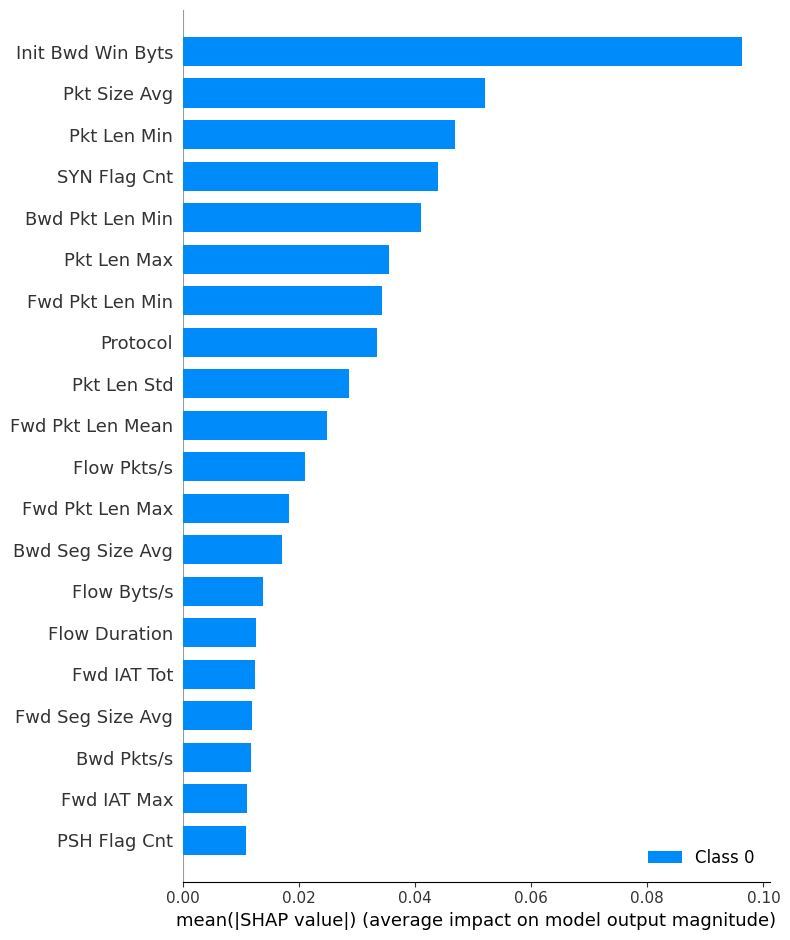

In [9]:
import matplotlib.pyplot as plt

print("[XAI] Generating IEEE-ready SHAP summary plot...")

plt.figure(figsize=(8, 5))  # IEEE single-column width
shap.summary_plot(
    shap_values,
    X_sample_flat,
    feature_names=feature_names,
    show=True
)

plt.title("Global Feature Importance using SHAP", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "shap_summary.png"), dpi=600)
plt.close()

[XAI] Generating SHAP bar plot...


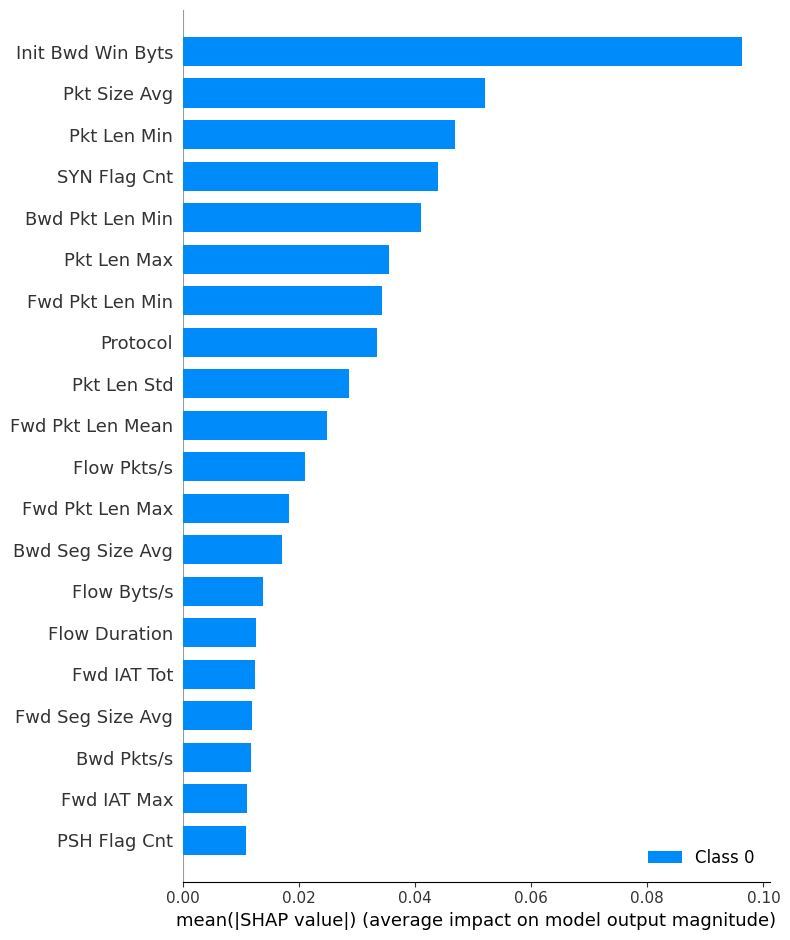

In [10]:
print("[XAI] Generating SHAP bar plot...")

plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values,
    X_sample_flat,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

plt.title("Top Contributing Features (SHAP)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "shap_bar.png"), dpi=600)
plt.close()

[XAI] Generating waterfall plot...


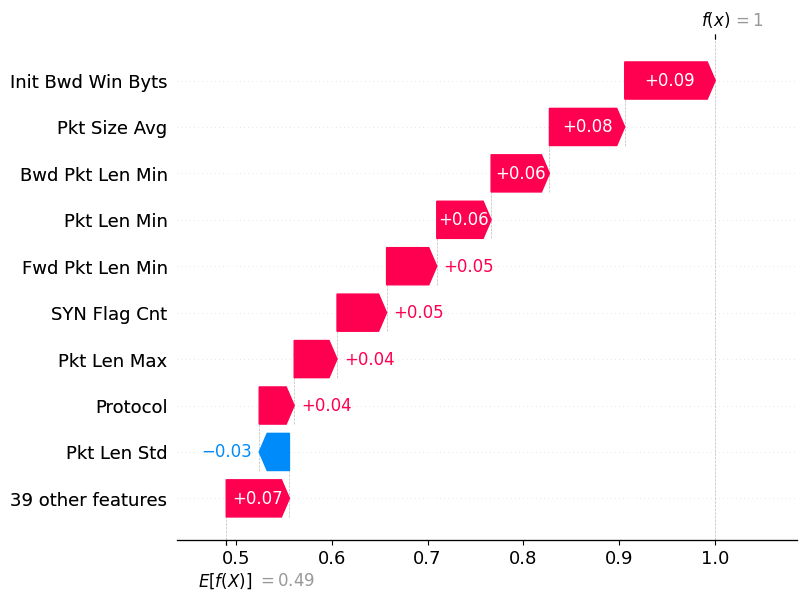

In [11]:
print("[XAI] Generating waterfall plot...")

# Select attack sample safely
attack_indices = np.where(y_test == 1)[0]
sample_idx = attack_indices[0] if len(attack_indices) > 0 else 0

# Fix SHAP values
if isinstance(shap_values, list):
    shap_single = shap_values[0][sample_idx]
    expected_value = explainer.expected_value[0]
else:
    shap_single = shap_values[sample_idx]
    expected_value = explainer.expected_value

sample_features = X_sample_flat[sample_idx]

plt.figure(figsize=(8, 5))
shap.plots._waterfall.waterfall_legacy(
    expected_value,          # ✅ FIXED (scalar now)
    shap_single,
    feature_names=feature_names,
    show=True
)

plt.title("Local Explanation for Attack Prediction", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "shap_waterfall.png"), dpi=600)
plt.close()

[XAI] Generating ranked feature importance plot...


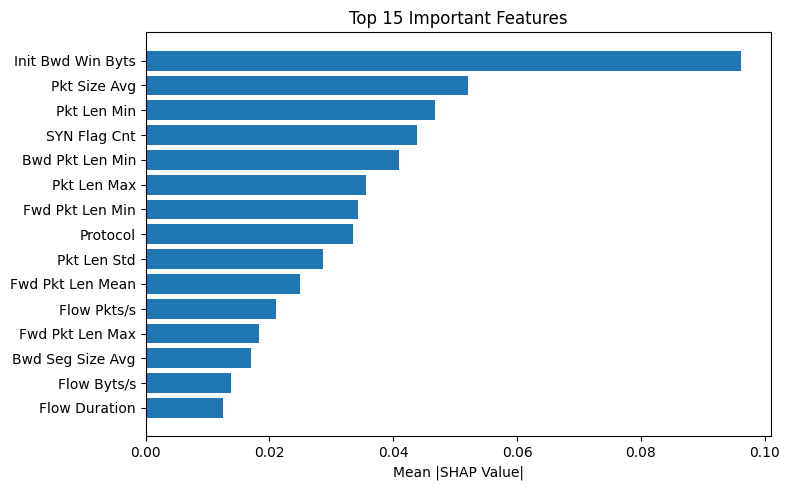

In [12]:
print("[XAI] Generating ranked feature importance plot...")

# Compute mean absolute SHAP values
if isinstance(shap_values, list):
    shap_vals = np.abs(shap_values[0])
else:
    shap_vals = np.abs(shap_values)

mean_shap = np.mean(shap_vals, axis=0)

# Sort features
indices = np.argsort(mean_shap)[::-1][:15]

top_features = [feature_names[i] for i in indices]
top_values = mean_shap[indices]

plt.figure(figsize=(8, 5))
plt.barh(top_features[::-1], top_values[::-1])
plt.xlabel("Mean |SHAP Value|")
plt.title("Top 15 Important Features")
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(results_dir, "shap_top_features.png"), dpi=600)
plt.close()

[XAI] Generating fidelity plot...
5165/5165 [==============================] - 5s 957us/step


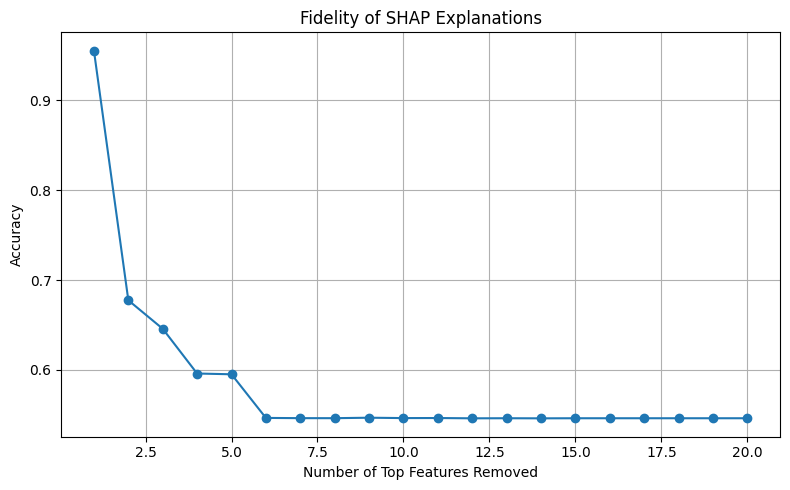

In [13]:
print("[XAI] Generating fidelity plot...")

k_values = list(range(1, 21))
accuracies = []

original_pred = global_model.predict(X_test)

for k in k_values:
    X_modified = X_test.copy()

    # remove top-k features
    important_idx = indices[:k]
    X_modified[:, 0, important_idx] = 0

    pred = global_model.predict(X_modified)
    acc = np.mean((pred > 0.5) == y_test.reshape(-1, 1))
    accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Top Features Removed")
plt.ylabel("Accuracy")
plt.title("Fidelity of SHAP Explanations")
plt.grid()
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(results_dir, "shap_fidelity.png"), dpi=600)
plt.close()